# Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
import geexhp
from geexhp import datavis as dvis

dvis.configure_matplotlib()

E0000 00:00:1785428895.753101  207529 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785428895.761303  207529 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785428895.784412  207529 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785428895.784457  207529 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785428895.784462  207529 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785428895.784465  207529 computation_placer.cc:177] computation placer already registered. Please check linka

# Write each filtered DataFrame to TFRecord files

In [ ]:
geexhp.tfrecord_conversion.create_tfrecords(
    root_folder="../parallel", save_root="../data/tfrecords"
)

🌍 Progress: |████████████████████          |  67% (503/753 files) ⏳ [58:39 elapsed]

In [2]:
geexhp.datasetup.concatenate_all_tfrecords(
    root_folder="../data/tfrecords",
    output_tfrecord_file="../data/all_samples.tfrecord",
)

Concatenated TFRecord file saved to '../data/all_samples.tfrecord'


# SNR MIN-MAX vs SNR PCTL

In [3]:
tfrecord_file = "../data/all_samples.tfrecord"

In [4]:
feature_description = {}
telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]

for base in bases:
    feature_description[f"SNR_FEATURE_{base}"] = tf.io.FixedLenFeature([], tf.float32)
    feature_description[f"SNR_FEATURE_PCTL_{base}"] = tf.io.FixedLenFeature(
        [], tf.float32
    )

orig_keys = [f"SNR_FEATURE_{base}" for base in bases]
pctl_keys = [f"SNR_FEATURE_PCTL_{base}" for base in bases]


def _parse_fn(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    orig = tf.stack([parsed[k] for k in orig_keys], axis=0)  # (6,)
    pctl = tf.stack([parsed[k] for k in pctl_keys], axis=0)  # (6,)
    return orig, pctl


batch_size = 4096
max_batches = None

ds = (
    tf.data.TFRecordDataset(tfrecord_file, num_parallel_reads=tf.data.AUTOTUNE)
    .map(_parse_fn, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

if max_batches is not None:
    ds = ds.take(max_batches)

orig_batches = []
pctl_batches = []

for orig_batch, pctl_batch in ds:
    orig_batches.append(orig_batch.numpy())  # (B, 6)
    pctl_batches.append(pctl_batch.numpy())  # (B, 6)

if orig_batches:
    orig_all = np.concatenate(orig_batches, axis=0)
    pctl_all = np.concatenate(pctl_batches, axis=0)
else:
    orig_all = np.empty((0, len(bases)), dtype=np.float32)
    pctl_all = np.empty((0, len(bases)), dtype=np.float32)

snr_data = {
    base: {"orig": orig_all[:, i], "pctl": pctl_all[:, i]}
    for i, base in enumerate(bases)
}

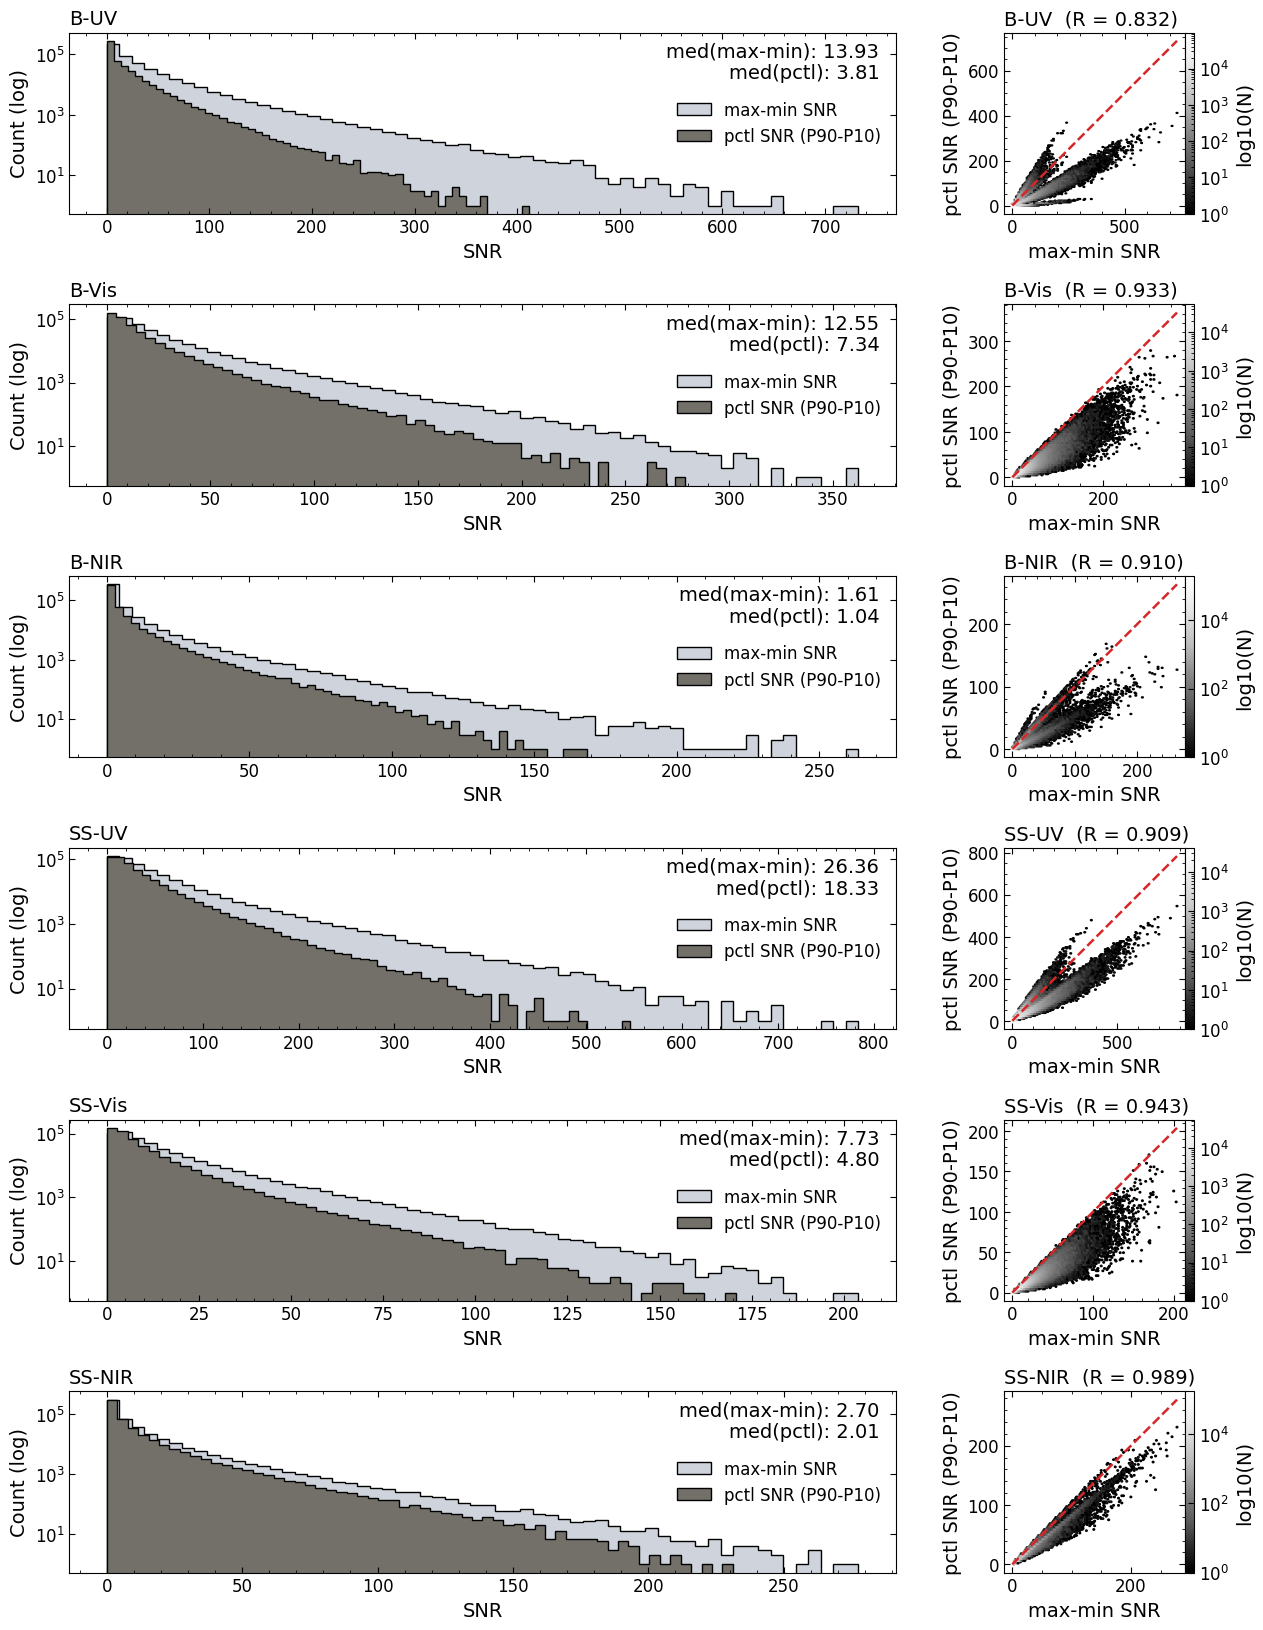

In [5]:
bases_plot = ["B-UV", "B-Vis", "B-NIR", "SS-UV", "SS-Vis", "SS-NIR"]
n_rows, n_cols = len(bases_plot), 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 20))

c_orig = "#ced3dc"
c_pctl = "#73706a"
c_diag = "tab:red"

for i, base in enumerate(bases_plot):
    x = snr_data[base]["orig"]
    y = snr_data[base]["pctl"]

    ax_hist = axes[i, 0]
    ax_rel = axes[i, 1]

    if x.size == 0 or y.size == 0:
        ax_hist.set_title(f"{base} (sem dados)")
        ax_rel.set_title(f"{base} (sem dados)")
        continue

    med_x = np.median(x)
    med_y = np.median(y)
    corr = np.corrcoef(x, y)[0, 1]

    ax_hist.hist(
        x,
        bins=60,
        color=c_orig,
        label="max-min SNR",
        edgecolor="k",
        histtype="stepfilled",
    )
    ax_hist.hist(
        y,
        bins=60,
        color=c_pctl,
        label="pctl SNR (P90-P10)",
        edgecolor="k",
        histtype="stepfilled",
    )
    ax_hist.set_yscale("log")
    ax_hist.set_xlabel("SNR")
    ax_hist.set_ylabel("Count (log)")
    ax_hist.set_title(f"{base}", loc="left")
    ax_hist.legend()

    ax_hist.text(
        0.98,
        0.95,
        f"med(max-min): {med_x:.2f}\nmed(pctl): {med_y:.2f}",
        transform=ax_hist.transAxes,
        ha="right",
        va="top",
    )

    hb = ax_rel.hexbin(x, y, gridsize=100, mincnt=1, bins="log", cmap="Grays_r")
    lim_min = float(min(x.min(), y.min()))
    lim_max = float(max(x.max(), y.max()))
    ax_rel.plot([lim_min, lim_max], [lim_min, lim_max], ls="--", lw=1.8, color=c_diag)
    ax_rel.set_aspect("equal", adjustable="box")

    ax_rel.set_xlabel("max-min SNR")
    ax_rel.set_ylabel("pctl SNR (P90-P10)")
    ax_rel.set_title(f"{base}  (R = {corr:.3f})", loc="left")
    cb = fig.colorbar(hb, ax=ax_rel, pad=0)
    cb.set_label("log10(N)")

plt.subplots_adjust(hspace=0.5, wspace=-0.5)
plt.show()

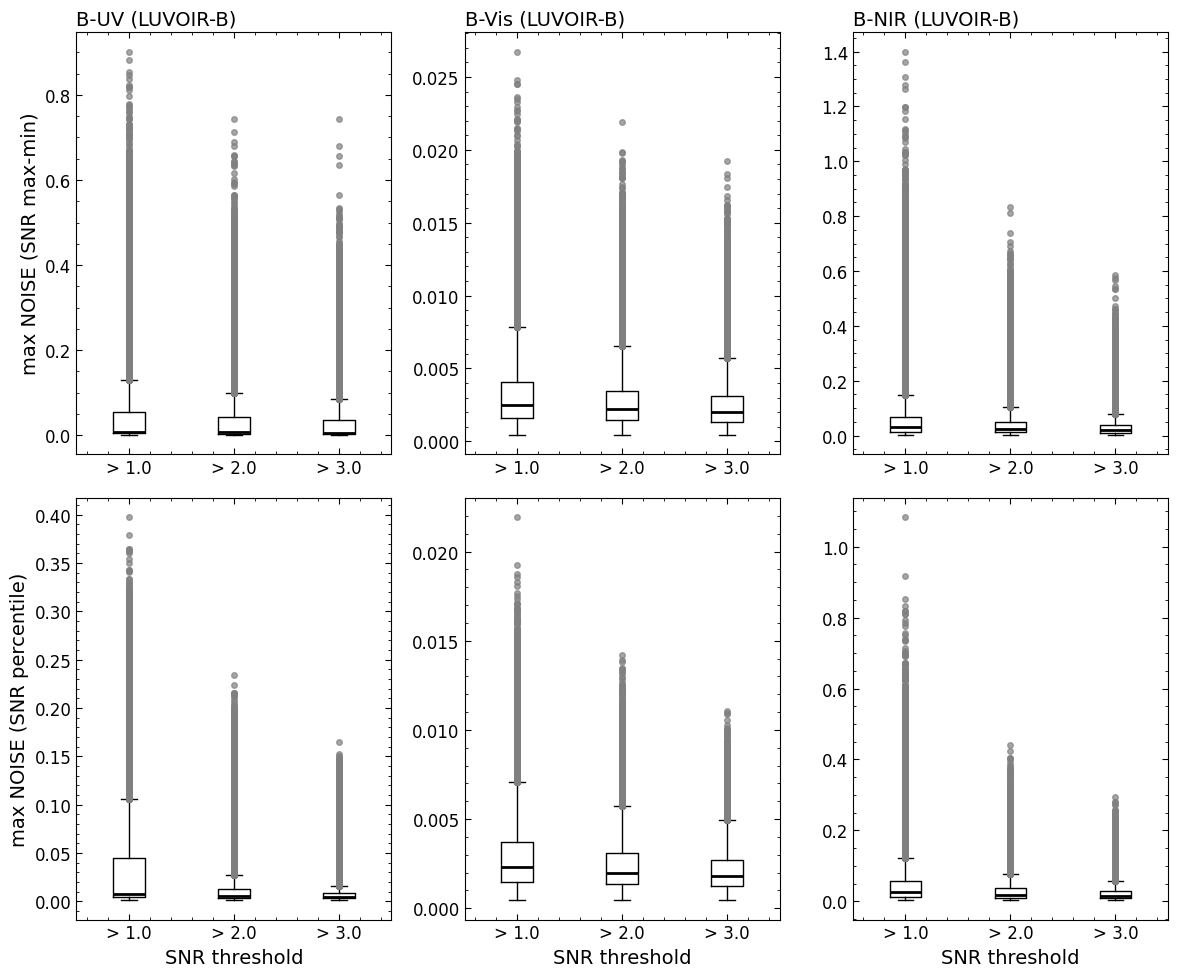

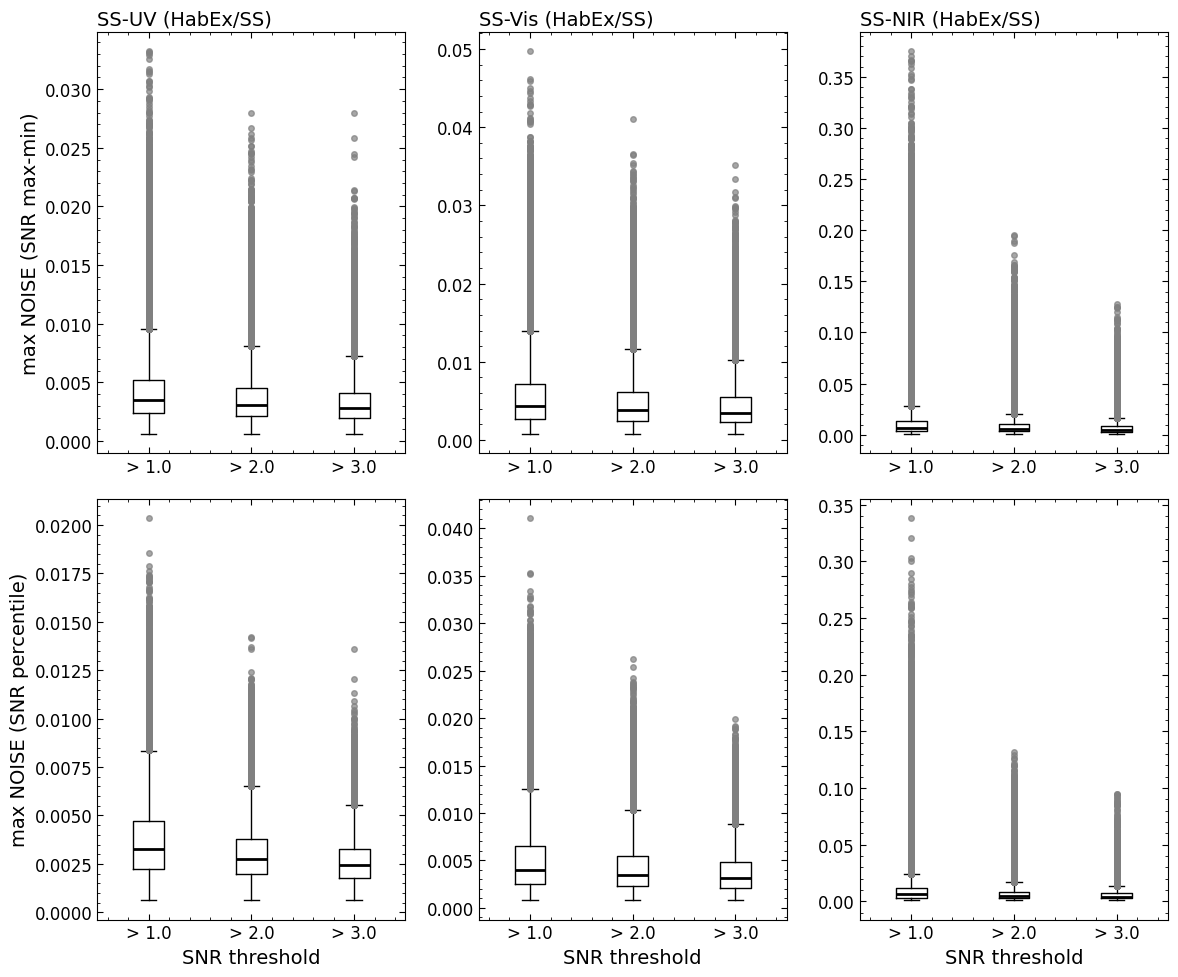

In [6]:
telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]
thresholds = [1.0, 2.0, 3.0]

feature_description = {
    **{f"SNR_FEATURE_{b}": tf.io.FixedLenFeature([], tf.float32) for b in bases},
    **{f"SNR_FEATURE_PCTL_{b}": tf.io.FixedLenFeature([], tf.float32) for b in bases},
    **{f"NOISE_{b}": tf.io.VarLenFeature(tf.float32) for b in bases},
}


def _parse_fn(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)

    snr_orig = tf.stack([parsed[f"SNR_FEATURE_{b}"] for b in bases], axis=0)  # (6,)
    snr_pctl = tf.stack(
        [parsed[f"SNR_FEATURE_PCTL_{b}"] for b in bases], axis=0
    )  # (6,)

    noise_max = tf.stack(
        [tf.reduce_max(tf.sparse.to_dense(parsed[f"NOISE_{b}"])) for b in bases],
        axis=0,
    )

    return snr_orig, snr_pctl, noise_max


max_batches = None
batch_size = 4096

ds = (
    tf.data.TFRecordDataset(tfrecord_file, num_parallel_reads=tf.data.AUTOTUNE)
    .map(_parse_fn, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)
if max_batches is not None:
    ds = ds.take(max_batches)

snr_orig_batches, snr_pctl_batches, noise_max_batches = [], [], []
for snr_orig_b, snr_pctl_b, noise_max_b in ds:
    snr_orig_batches.append(snr_orig_b.numpy())
    snr_pctl_batches.append(snr_pctl_b.numpy())
    noise_max_batches.append(noise_max_b.numpy())

snr_orig_mat = (
    np.concatenate(snr_orig_batches, axis=0)
    if snr_orig_batches
    else np.empty((0, len(bases)))
)
snr_pctl_mat = (
    np.concatenate(snr_pctl_batches, axis=0)
    if snr_pctl_batches
    else np.empty((0, len(bases)))
)
noise_max_mat = (
    np.concatenate(noise_max_batches, axis=0)
    if noise_max_batches
    else np.empty((0, len(bases)))
)

mask_finite = (
    np.isfinite(snr_orig_mat).all(axis=1)
    & np.isfinite(snr_pctl_mat).all(axis=1)
    & np.isfinite(noise_max_mat).all(axis=1)
)
snr_orig_mat = snr_orig_mat[mask_finite]
snr_pctl_mat = snr_pctl_mat[mask_finite]
noise_max_mat = noise_max_mat[mask_finite]

idx_map = {base: i for i, base in enumerate(bases)}


def select_noise_groups(snr_mat, noise_col, thr_list):
    groups = []
    for thr in thr_list:
        keep = (snr_mat > thr).all(axis=1)
        vals = noise_col[keep]
        groups.append(vals if vals.size else np.array([np.nan]))
    return groups


row_specs = [
    ("max NOISE (SNR max-min)", snr_orig_mat),
    ("max NOISE (SNR percentile)", snr_pctl_mat),
]

for tel in telescopes:
    fig, axes = plt.subplots(2, 3, figsize=(12, 10))
    tel_label = {"B": "LUVOIR-B", "SS": "HabEx/SS"}

    for j, band in enumerate(bands):
        base = f"{tel}-{band}"
        idx = idx_map[base]
        noise_col = noise_max_mat[:, idx]

        for row, (ylabel, snr_mat) in enumerate(row_specs):
            ax = axes[row, j]
            data = select_noise_groups(snr_mat, noise_col, thresholds)
            ax.boxplot(
                data,
                tick_labels=[f"> {t}" for t in thresholds],
                flierprops=dict(
                    marker="o",
                    markerfacecolor="gray",
                    markeredgecolor="gray",
                    markersize=4,
                    alpha=0.7,
                ),
                medianprops=dict(color="black", linewidth=2),
            )
            if row == 0:
                ax.set_title(f"{base} ({tel_label[tel]})", loc="left")
            if j == 0:
                ax.set_ylabel(ylabel)
            if row == 1:
                ax.set_xlabel("SNR threshold")

    plt.tight_layout()
    plt.show()

# Train/Validation/Test split (SNR PCTL > 3)

In [7]:
telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]

feature_description = {
    "Earth_type": tf.io.FixedLenFeature([], tf.string),
}
for base in bases:
    feature_description[f"SNR_FEATURE_PCTL_{base}"] = tf.io.FixedLenFeature(
        [], tf.float32
    )


def parse_example(serialized):
    parsed = tf.io.parse_single_example(serialized, feature_description)
    earth = parsed["Earth_type"].numpy().decode("utf-8")
    snr_vals = np.array(
        [parsed[f"SNR_FEATURE_PCTL_{base}"].numpy() for base in bases],
        dtype=np.float32,
    )
    return earth, snr_vals


raw_ds = tf.data.TFRecordDataset(tfrecord_file)

examples_by_era = defaultdict(list)

N_total = 0
N_keep = 0

for raw in raw_ds:
    serialized = raw.numpy()
    N_total += 1

    earth, snr_vals = parse_example(serialized)

    if np.isfinite(snr_vals).all() and (snr_vals > 3.0).all():
        examples_by_era[earth].append(serialized)
        N_keep += 1

print(f"Total examples read     : {N_total}")
print(f"Examples with SNR_pctl > 3 in all bands: {N_keep}")

for era, ex_list in examples_by_era.items():
    print(f"  {era}: {len(ex_list)} examples")

rng = np.random.default_rng(42)

train_examples = []
val_examples = []
test_examples = []

for era, ex_list in examples_by_era.items():
    ex_array = np.array(ex_list, dtype=object)
    rng.shuffle(ex_array)

    n = len(ex_array)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)
    n_test = n - n_train - n_val

    train_era = ex_array[:n_train]
    val_era = ex_array[n_train : n_train + n_val]
    test_era = ex_array[n_train + n_val :]

    train_examples.extend(train_era.tolist())
    val_examples.extend(val_era.tolist())
    test_examples.extend(test_era.tolist())

    print(f"\nEra = {era}")
    print(f"  total   : {n}")
    print(f"  train   : {len(train_era)}")
    print(f"  val     : {len(val_era)}")
    print(f"  test    : {len(test_era)}")

rng.shuffle(train_examples)
rng.shuffle(val_examples)
rng.shuffle(test_examples)

print("\nFinal split sizes:")
print(f"  train: {len(train_examples)}")
print(f"  val  : {len(val_examples)}")
print(f"  test : {len(test_examples)}")

train_path = os.path.join("../data", "train.tfrecord")
val_path = os.path.join("../data", "val.tfrecord")
test_path = os.path.join("../data", "test.tfrecord")


def write_tfrecord(path, serialized_list):
    with tf.io.TFRecordWriter(path) as w:
        for ex in serialized_list:
            w.write(ex)


write_tfrecord(train_path, train_examples)
write_tfrecord(val_path, val_examples)
write_tfrecord(test_path, test_examples)

print("\nSaved TFRecords:")
print("  ", train_path)
print("  ", val_path)
print("  ", test_path)

Total examples read     : 482746
Examples with SNR_pctl > 3 in all bands: 109945
  proterozoic: 36996 examples
  modern: 39431 examples
  archean: 33518 examples

Era = proterozoic
  total   : 36996
  train   : 29596
  val     : 3699
  test    : 3701

Era = modern
  total   : 39431
  train   : 31544
  val     : 3943
  test    : 3944

Era = archean
  total   : 33518
  train   : 26814
  val     : 3351
  test    : 3353

Final split sizes:
  train: 87954
  val  : 10993
  test : 10998

Saved TFRecords:
   ../data/train.tfrecord
   ../data/val.tfrecord
   ../data/test.tfrecord


In [ ]:
def merge_tfrecords(inputs, output, input_compression=None, output_compression=None):
    ds = tf.data.TFRecordDataset(
        inputs, compression_type=input_compression, num_parallel_reads=tf.data.AUTOTUNE
    )

    options = None
    if output_compression:
        options = tf.io.TFRecordOptions(compression_type=output_compression)

    writer = tf.io.TFRecordWriter(output, options=options)
    for raw in ds:
        writer.write(raw.numpy())
    writer.close()


merge_tfrecords(
    inputs=["../data/train.tfrecord", "../data/val.tfrecord", "../data/test.tfrecord"],
    output="../data/all_selected_sample.tfrecord",
    input_compression=None,
    output_compression=None,
)

In [10]:
def count_records(path, compression=None):
    return sum(1 for _ in tf.data.TFRecordDataset(path, compression_type=compression))


print("train:", count_records("../data/train.tfrecord"))
print("val:", count_records("../data/val.tfrecord"))
print("test:", count_records("../data/test.tfrecord"))
print("all:", count_records("../data/all_selected_sample.tfrecord"))

train: 87954
val: 10993
test: 10998
all: 109945


# Reading TFRecord file

In [11]:
# Parsing function.
def parse_example(example_proto, feature_description):
    # Parse the example.
    parsed_features = tf.io.parse_single_example(example_proto, feature_description)

    # Convert SparseTensors to DenseTensors.
    #   This is necessary because we loaded features with variable length.
    #   Although the parsed files have the desired data, they have other things
    #   (indices, values and dense_shape). Neural networks must work with values
    #   in a more direct way.
    dense_features = {
        key: (
            tf.sparse.to_dense(value, default_value=0.0)
            if isinstance(value, tf.SparseTensor)
            else value
        )
        for key, value in parsed_features.items()
    }

    return dense_features

In [12]:
tfrecord_file = "../data/all_selected_sample.tfrecord"

## Read TFRecords with unknown feature_description

In [13]:
# Read the TFRecord.
raw_dataset = tf.data.TFRecordDataset(tfrecord_file)

In [14]:
# Inspect and parse a single record to infer feature names.
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print(example)  # Inspect the parsed example
    break

features {
  feature {
    key: "SNR_SS-Vis"
    value {
      float_list {
        value: 47.9820557
        value: 47.9322777
        value: 48.0387306
        value: 48.0593529
        value: 48.3441696
        value: 48.4679565
        value: 48.3401756
        value: 48.5667114
        value: 48.7736092
        value: 48.68853
        value: 48.5187111
        value: 48.2151222
        value: 48.8244286
        value: 49.0821877
        value: 49.0971375
        value: 48.3995743
        value: 45.6878433
        value: 46.414505
        value: 48.2963524
        value: 48.9096031
        value: 48.7405434
        value: 48.29459
        value: 47.7594223
        value: 47.5282745
        value: 47.4268951
        value: 46.6907692
        value: 43.5063972
        value: 43.7609825
        value: 46.2637062
        value: 46.7251129
        value: 46.422123
        value: 46.032093
        value: 45.5041351
        value: 42.542942
        value: 42.2954712
        value: 43.0253

In [15]:
# Dynamically build an infered_feature_description
# Parse the inspected "example" to infer the feature description
infered_feature_description = {}
for key, value in example.features.feature.items():
    # Determine the type of the feature
    if value.HasField("bytes_list"):
        if len(value.bytes_list.value) > 1:  # Check for multiple values
            infered_feature_description[key] = tf.io.VarLenFeature(tf.string)
        else:
            infered_feature_description[key] = tf.io.FixedLenFeature([], tf.string)
    elif value.HasField("float_list"):
        if len(value.float_list.value) > 1:  # Check for multiple values
            infered_feature_description[key] = tf.io.VarLenFeature(tf.float32)
        else:
            infered_feature_description[key] = tf.io.FixedLenFeature([], tf.float32)
    elif value.HasField("int64_list"):
        if len(value.int64_list.value) > 1:  # Check for multiple values
            infered_feature_description[key] = tf.io.VarLenFeature(tf.int64)
        else:
            infered_feature_description[key] = tf.io.FixedLenFeature([], tf.int64)

In [16]:
infered_feature_description

{'NOISY_ALBEDO_B-NIR': VarLenFeature(dtype=tf.float32),
 'SNR_FEATURE_SS-NIR': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'SNR_B-Vis': VarLenFeature(dtype=tf.float32),
 'NOISE_B-UV': VarLenFeature(dtype=tf.float32),
 'NOISY_ALBEDO_B-UV': VarLenFeature(dtype=tf.float32),
 'SNR_SS-Vis': VarLenFeature(dtype=tf.float32),
 'OBJECT-GRAVITY': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'SNR_SS-UV': VarLenFeature(dtype=tf.float32),
 'NOISY_ALBEDO_SS-Vis': VarLenFeature(dtype=tf.float32),
 'ALBEDO_B-Vis': VarLenFeature(dtype=tf.float32),
 'OBJECT-SOLAR-LONGITUDE': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'ALBEDO_B-NIR': VarLenFeature(dtype=tf.float32),
 'GEOMETRY-OBS-ALTITUDE': FixedLenFeature(shape=[], dtype=tf.float32, default_value=None),
 'NOISE_B-NIR': VarLenFeature(dtype=tf.float32),
 'ALBEDO_SS-UV': VarLenFeature(dtype=tf.float32),
 'ALBEDO_SS-Vis': VarLenFeature(dtype=tf.float32),
 'SNR_SS-NIR': VarLenFeature(dtype=tf

In [17]:
parsed_dataset = raw_dataset.map(
    lambda x: parse_example(x, infered_feature_description)
)

# Step 5: Iterate through the parsed dataset
for parsed_record in parsed_dataset.take(1):  # Show the first record
    print(parsed_record)

{'ALBEDO_B-NIR': <tf.Tensor: shape=(49,), dtype=float32, numpy=
array([1.0181679e-02, 3.0139089e-02, 6.7927174e-02, 7.8045808e-02,
       7.4641012e-02, 5.9548993e-02, 2.8902134e-02, 1.6059336e-03,
       9.1698857e-05, 6.3676314e-05, 4.1356114e-05, 7.8511970e-05,
       2.4584085e-03, 1.8472837e-02, 2.8106337e-02, 6.0496476e-02,
       6.8891749e-02, 6.2174089e-02, 1.4579454e-02, 1.8131947e-03,
       5.9351398e-05, 1.8878023e-05, 1.5972682e-05, 1.8296541e-05,
       3.4560482e-05, 6.1534636e-05, 1.8232691e-04, 1.4956807e-03,
       1.9344199e-02, 4.4162780e-02, 6.1257843e-02, 4.8631474e-02,
       5.5426590e-02, 6.2047858e-03, 1.3304295e-04, 2.6316913e-05,
       2.1699887e-05, 1.4660380e-05, 1.3038916e-05, 1.7775248e-05,
       1.8256122e-05, 1.7851375e-05, 8.3699024e-06, 8.1140479e-06,
       9.2521759e-06, 1.0189158e-05, 2.8918263e-05, 3.6662708e-03,
       1.0341943e-02], dtype=float32)>, 'ALBEDO_B-UV': <tf.Tensor: shape=(8,), dtype=float32, numpy=
array([0.03477792, 0.00674999, 